In [1]:
import sys
sys.path.append('..')

In [ ]:
import os
import pandas as pd
import torch

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from chunkformer import ChunkFormerModel
from torchmetrics.functional import (
    audio as func_audio,
    text as func_text
)

from utils import draw_spec, show_audios
from src.training_and_inference.datasets import AudioDataset
from src.training_and_inference.nlp_utils import preprocess_vn_text
from src.training_and_inference.training_utils import load_wav2vec2

from IPython.display import display, clear_output


device = 'cuda'

In [3]:
def compute_metrics(signals, sr):
    return {
        "dnsmos": func_audio.deep_noise_suppression_mean_opinion_score(
            signals, sr, False, device='cuda'
        ),
        "nisqa": func_audio.non_intrusive_speech_quality_assessment(signals, sr)
    }

def compute_wer(preds, targets):
    return func_text.word_error_rate(preprocess_vn_text(preds), preprocess_vn_text(targets))

In [4]:
with open('test-audio/random.txt') as file:
    targets = file.read().splitlines()

origin_dir = "test-audio/random"
denoised_dirs = [
    "test-audio/denoised-random-baseline",
    "test-audio/denoised-random-6150",
    "test-audio/denoised-random-9963",
    "test-audio/denoised-random-15621",
]

original_files = sorted([f"{origin_dir}/{file}" for file in os.listdir(origin_dir)])
original_audio = AudioDataset(original_files, sample_rate=16000)

denoised_samples = {'files': [
    sorted([f"{dir}/{file}" for file in os.listdir(dir)])
    for dir in denoised_dirs
] }
denoised_samples['audios'] = [AudioDataset(files, sample_rate=16000) for files in denoised_samples['files']]

# Checkpoints

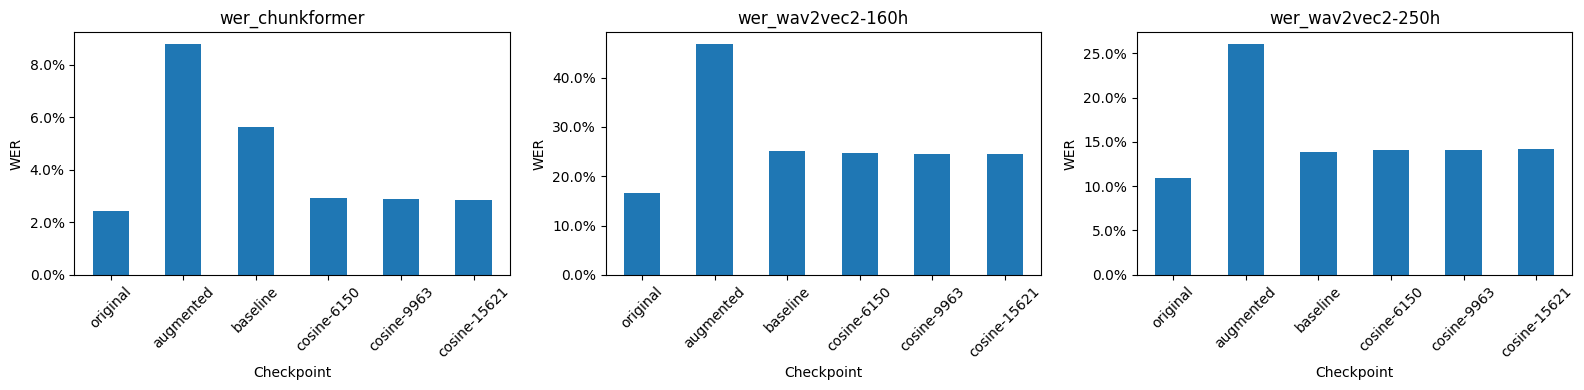

In [ ]:
eval_res = pd.read_csv('results.csv', index_col=[0, -1])

fig = plt.figure(figsize=(16, 4))
axes = fig.subplots(1, 3)

metrics = eval_res[eval_res.index.get_level_values(-1) == 'test'].reset_index(1) * 100
for i, category in enumerate(['wer_chunkformer', 'wer_wav2vec2-160h', 'wer_wav2vec2-250h']):
    metrics.plot.bar(
        y=category,
        rot=45,
        ax=axes[i],
        xlabel='Checkpoint',
        ylabel='WER',
        title=category,
        legend=False
    )
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    
fig.tight_layout()

In [6]:
models = {
    "wav2vec2-160h": load_wav2vec2(
        "khanhld/wav2vec2-base-vietnamese-160h",
        freeze_model=False,
        return_loss_fn=False
    ),
    "wav2vec2-250h": load_wav2vec2(
        "nguyenvulebinh/wav2vec2-base-vietnamese-250h",
        freeze_model=False,
        return_loss_fn=False
    ),
    "chunkformer": ChunkFormerModel.from_pretrained(
        "khanhld/chunkformer-ctc-large-vie"
    ).eval().to(device)
}
models['wav2vec2-160h'][1].eval().to(device)
models['wav2vec2-250h'][1].eval().to(device)

def wav2vec2_transcribe(wav, processor, stt_model):
    input_values = processor(wav, sampling_rate=16000, return_tensors="pt").input_values
    logits = stt_model(input_values.to(device)).logits
    pred_ids = torch.argmax(logits, dim=-1)
    return processor.batch_decode(pred_ids)

def chunkformer_transcribe(audio_file, chunkformer=None):
    if chunkformer is None:
        chunkformer = models['chunkformer']
    return chunkformer.endless_decode(
        audio_path=audio_file,
        return_timestamps=False
    )

Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/213 [00:00<?, ?it/s]

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

# Comparison

In [7]:
import textwrap
import math

def show_transcriptions(
    transcriptions,
    target_transcription,
    titles=None,
    *,
    wrap_width=40,
    col_sep=" | "
):
    wers = [compute_wer([t], [target_transcription]) for t in transcriptions]
    wrapped_txts = [textwrap.wrap(t, width=wrap_width) for t in transcriptions]
    max_lines = max(len(i) for i in wrapped_txts)

    wer_format = col_sep.join([f"{{:^{wrap_width}}}"] * len(wrapped_txts))
    row_format = col_sep.join([f"{{:<{wrap_width}}}"] * len(wrapped_txts))

    def get_line(line_list, idx):
        return line_list[idx] if idx < len(line_list) else ""

    if titles:
        print(wer_format.format(*titles))
    print(
        "_" * (wrap_width * len(wrapped_txts) + 9),
        wer_format.format(*(f"WER: {wer:.2%}" for wer in wers)),
        sep='\n'
    )
    for i in range(max_lines):
        print(row_format.format(*(get_line(lines, i) for lines in wrapped_txts)))
    print("_" * (wrap_width * len(wrapped_txts) + 9))

def show_res(
    audios,
    transcriptions,
    original_audio,
    target_transcription,
    titles=None,
    wrap_width=40,
    col_sep=" | "
):
    print(f"\033[1mTarget Transcription:\033[0m {target_transcription}")

    display(show_audios([(original_audio, 16000)]))
    display(show_audios([
        [(wf, 16000) for wf in audios]
    ]))
    
    show_transcriptions(
        transcriptions,
        target_transcription,
        titles,
        wrap_width=wrap_width,
        col_sep=col_sep
    )

def generate_mosaic_layout(n):
    """Calculates grid dimensions aiming for a square shape, then returns a mosaic layout."""
    if n == 0:
        return [["."]]

    side = int(math.sqrt(n))

    num_cols = side
    num_rows = side

    while num_cols * num_rows < n:
        if num_cols <= num_rows:
            num_cols += 1
        else:
            num_rows += 1

    layout = []
    for r in range(num_rows):
        row = []
        for c in range(num_cols):
            index = r * num_cols + c
            row.append(index if index < n else ".")
        layout.append(row)

    return layout

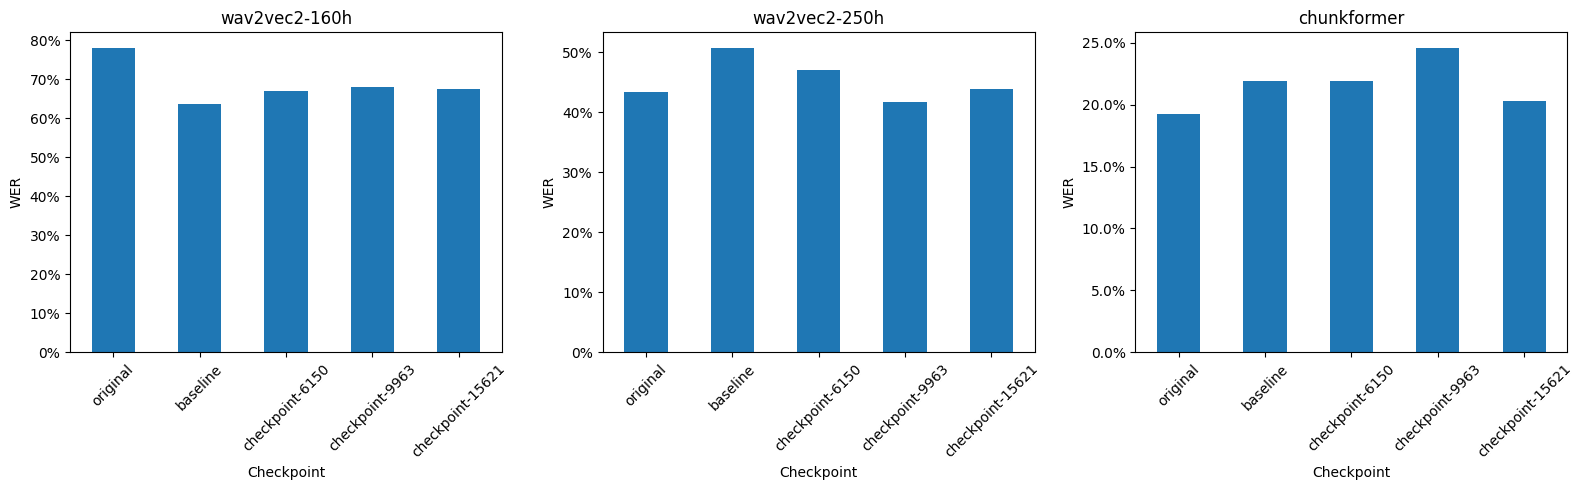

In [18]:
ckpts = [
    'baseline',
    'checkpoint-6150',
    'checkpoint-9963',
    'checkpoint-15621'
]
random_metrics = {
    name: [
        compute_wer([
            wav2vec2_transcribe(wf, *models[f'wav2vec2-{num}0h'])[0]
            for wf in denoised_samples['audios'][i]
        ], targets) for num in (16, 25)
    ]
    for i, name in enumerate(ckpts)
}
random_metrics['original'] = [
    compute_wer([
        wav2vec2_transcribe(wf, *models[f'wav2vec2-{num}0h'])[0]
        for wf in original_audio
    ], targets) for num in (16, 25)
]
random_metrics['original'].append(compute_wer(
    [chunkformer_transcribe(file) for file in original_files],
    targets
))

for name, files in zip(ckpts, denoised_samples['files']):
    random_metrics[name].append(compute_wer(
    [chunkformer_transcribe(file) for file in files],
    targets
))

clear_output()

df = pd.DataFrame(random_metrics, dtype=float)
df = df[['original', *list(df.columns[:-1])]]

fig = plt.figure(figsize=(16, 5))
axes = fig.subplots(1, 3)
for i, model in enumerate(['wav2vec2-160h', 'wav2vec2-250h', 'chunkformer']):
    (df.loc[i] * 100).plot.bar(
        rot=45,
        ax=axes[i],
        xlabel='Checkpoint',
        ylabel='WER',
        title=model,
    )
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

fig.tight_layout()
plt.show()

In [38]:
idx = 0
wrap_width = 45

ckpt_names = ['Original', 'Baseline', 'Checkpoint 6150', 'Checkpoint 9963', 'Checkpoint 15621']
denoised_files = [files[idx] for files in denoised_samples['files']]
audios = [dataset[idx] for dataset in denoised_samples['audios']]
transcribe_audio = [original_audio[idx]] + audios
trans = [chunkformer_transcribe(file) for file in [original_files[idx]] + denoised_files]

clear_output()
show_res(
    audios,
    trans,
    original_audio[idx],
    targets[idx],
    ckpt_names,
    wrap_width=wrap_width
)

print("\n\033[1mWav2Vec2-160h Transcriptions\033[0m")
show_transcriptions(
    [wav2vec2_transcribe(wf, *models['wav2vec2-160h'])[0] for wf in transcribe_audio],
    targets[idx],
    wrap_width=wrap_width
)

print("\n\033[1mWav2Vec2-250h Transcriptions\033[0m")
show_transcriptions(
    [wav2vec2_transcribe(wf, *models['wav2vec2-250h'])[0] for wf in transcribe_audio],
    targets[idx],
    wrap_width=wrap_width
)


Target Transcription: hôm nay tôi nhận được cái bằng, công nhận đây là cái niềm vinh hạnh lớn nhất của đời một người thợ ráng cố gắng gìn giữ nghề truyền thống để truyền lại cho thế hệ mai sau


                  Original                    |                   Baseline                    |                Checkpoint 6150                |                Checkpoint 9963                |               Checkpoint 15621               
__________________________________________________________________________________________________________________________________________________________________________________________________________________________________________
                 WER: 6.67%                   |                  WER: 13.33%                  |                  WER: 3.33%                   |                  WER: 3.33%                   |                  WER: 6.67%                  
hôm nay con nhận được cái bằng công nhận đây  | hôm nay con nhận được cái bằng công nhận đây  | hôm nay tôi nhận được cái bằng công nhận đây  | hôm nay tôi nhận được cái bằng công nhận đây  | hôm nay con nhận được cái bằng công nhận đây 
là cái niềm vinh hạnh lớn nhất của đời một    | là 

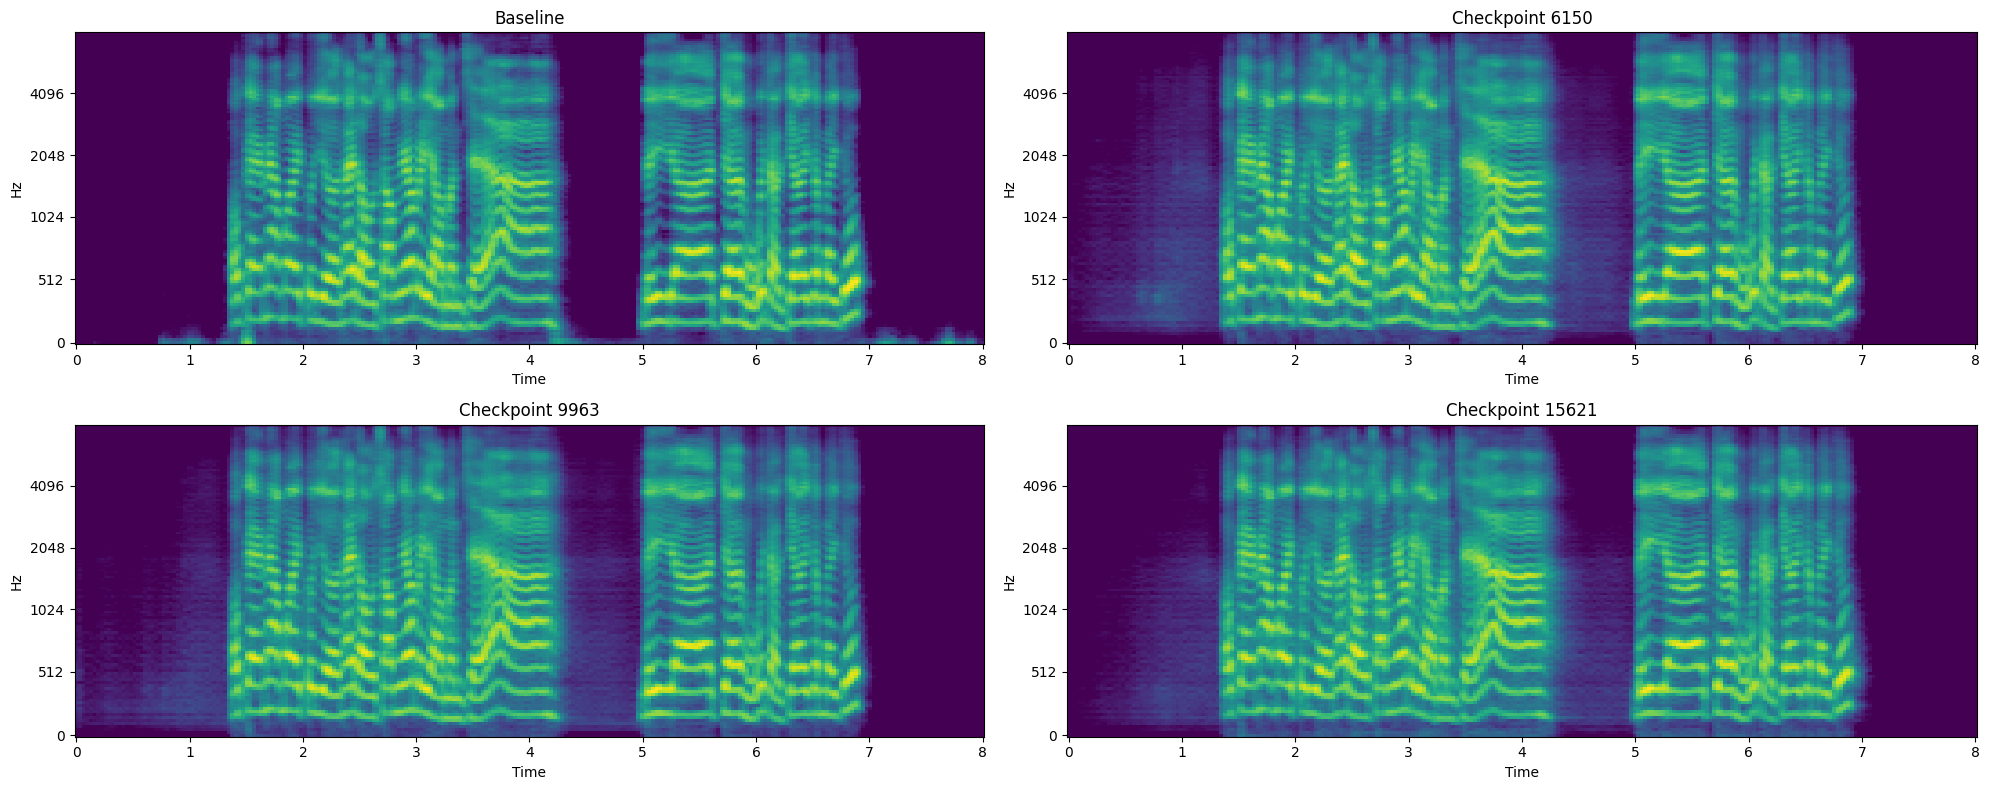

In [29]:
fig, axes = plt.subplot_mosaic(
    generate_mosaic_layout(len(audios)),
    figsize=(20, 8)
)

for i, (wf, name) in enumerate(zip(audios, ckpt_names[1:])):
    draw_spec(
        wf.numpy(),
        16000,
        name=name,
        ax=axes[i]
    )

fig.tight_layout()
plt.show()